### Objectives

High-level EDA - just to "get knowing the data". Discover distribution of columns, evaluate missing data, get first impression.

In [1]:
import pandas as pd


# 1. ALL DATA (PRE-FILTER, MIXED COUNTRIES)

This section covers core checks and time-pattern EDA on the full working dataset.

In [60]:
df = pd.read_csv("../data/online_retail_II.csv")
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [61]:
df.describe()


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [62]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

- Roughly 20-25% of transactional rows have missing `CustomerID` (guest/unregistered buyers).
- These are a special-case business scenario, not random missing sensor data.

We will replace empty `CustomerID` special value: -1.

In [28]:
GUEST_CUSTOMER_ID = -1

df["Customer ID"] = df["Customer ID"].fillna(GUEST_CUSTOMER_ID)

In [63]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [64]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1067366    False
1067367    False
1067368    False
1067369    False
1067370    False
Length: 1067371, dtype: bool

## Country Concentration
Quickly inspect the dominant countries by transaction volume before applying the UK-only scope.

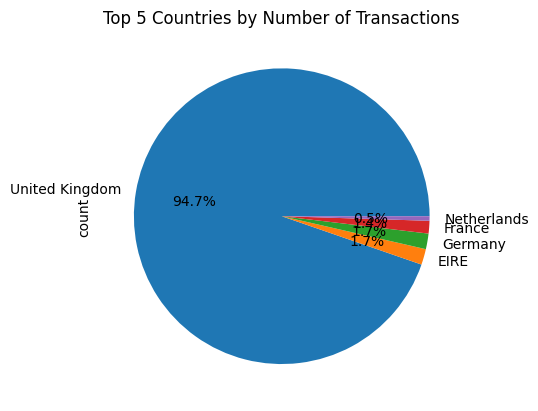

In [31]:
top_countries = df["Country"].value_counts().head(5)
top_countries.plot(
    kind="pie", autopct="%1.1f%%", title="Top 5 Countries by Number of Transactions"
);

## UK Scope And Weekly Pattern
Restrict the dataset to UK transactions in-place, then inspect transaction volume by day of week.

In [32]:
df.drop(df[df["Country"] != "United Kingdom"].index, inplace=True)

df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Month"] = df["InvoiceDate"].dt.month_name()

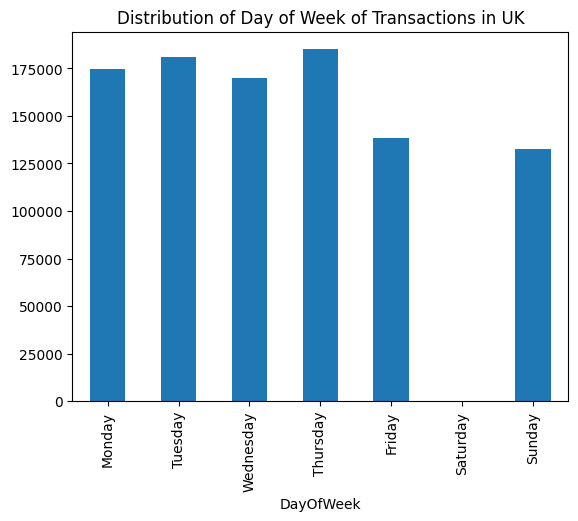

In [33]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
df["DayOfWeek"].value_counts().reindex(day_order).plot(
    kind="bar", title="Distribution of Day of Week of Transactions in UK"
);

## Monthly Seasonality (UK)
Inspect how transaction counts vary across calendar months in the UK-only dataset.

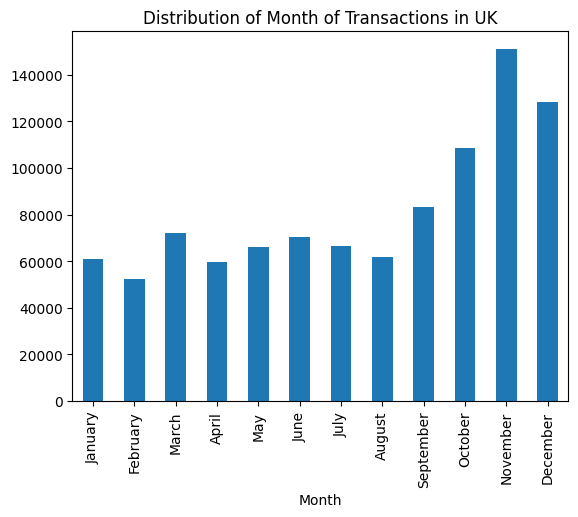

In [34]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
df["Month"].value_counts().reindex(month_order).plot(
    kind="bar", title="Distribution of Month of Transactions in UK"
);


## Hourly Pattern (UK)
Inspect transaction counts by hour of day after date parsing.

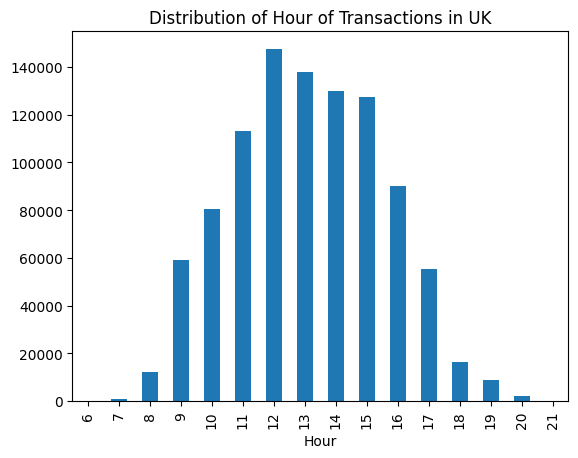

In [51]:
df["Hour"].value_counts().sort_index().plot(
    kind="bar", title="Distribution of Hour of Transactions in UK"
);

## StockCode Frequency
Visualize how frequently StockCode values appear in transactions.

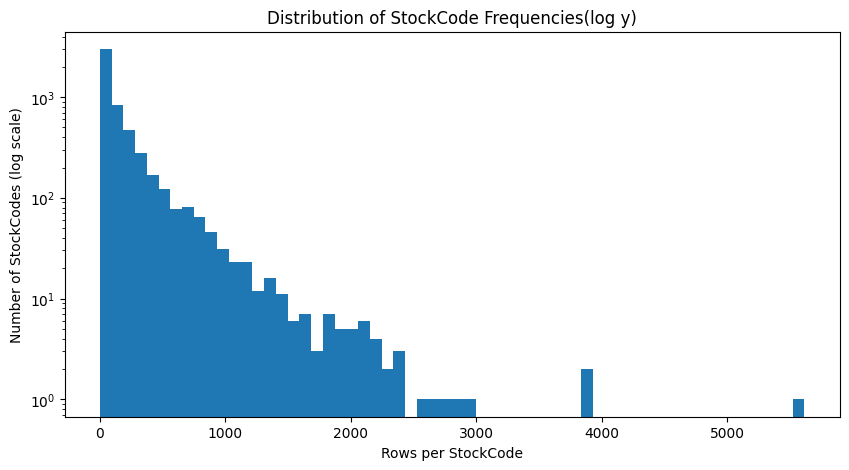

In [52]:
stockcode_counts = df["StockCode"].value_counts(dropna=False)

ax = stockcode_counts.plot(
    kind="hist",
    bins=60,
    logy=True,
    figsize=(10, 5),
    title="Distribution of StockCode Frequencies(log y)",
)

ax.set_xlabel("Rows per StockCode")
ax.set_ylabel("Number of StockCodes (log scale)");

## Quantity Distribution
Plot quantities after clipping extreme tails using 5th and 95th percentiles.

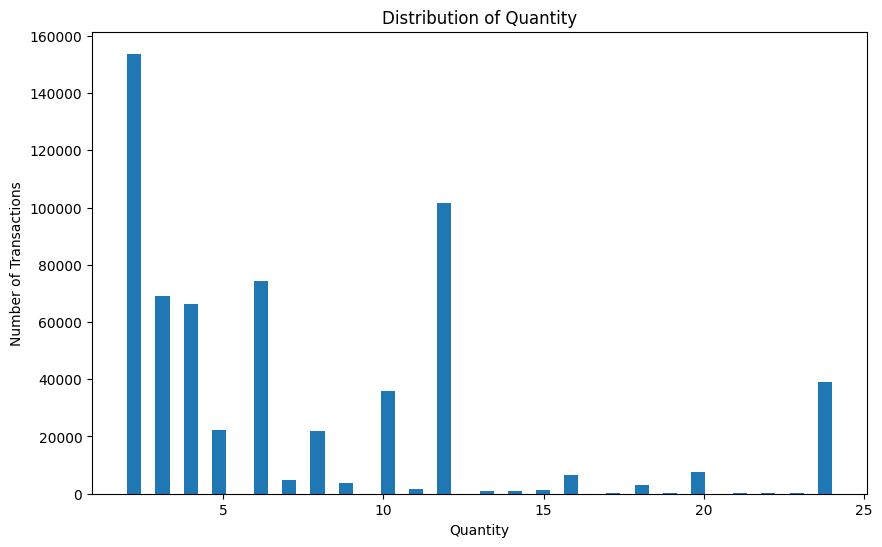

In [54]:
q_low = df["Quantity"].quantile(0.05)
q_high = df["Quantity"].quantile(0.95)
plot_df = df[
    (df["Quantity"] > q_low) & (df["Quantity"] < q_high)
]

ax = plot_df["Quantity"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 6),
    title="Distribution of Quantity",
)

ax.set_xlabel("Quantity")
ax.set_ylabel("Number of Transactions");

## Unit Price Distribution
Plot prices after clipping extreme tails using 5th and 95th percentiles.

Text(0, 0.5, 'Number of Transactions')

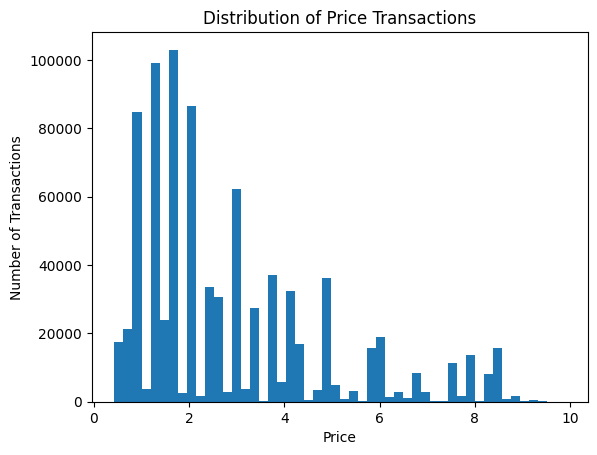

In [55]:
q_low = df["Price"].quantile(0.05)
q_high = df["Price"].quantile(0.95)
plot_df = df[(df["Price"] > q_low) & (df["Price"] < q_high)]

ax = plot_df["Price"].plot(
    kind="hist", bins=50, title="Distribution of Price Transactions"
)

ax.set_xlabel("Price")
ax.set_ylabel("Number of Transactions")


Plot distribution of total-spent per order

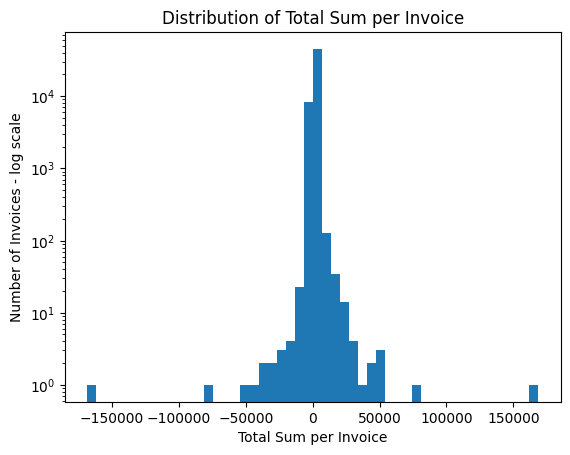

In [67]:
# calculate total sum per invoice for each invoice: group by invoice, multiply quantity by price, and sum the total for each invoice
df_total_per_invoice = df.groupby("Invoice").apply(
    lambda x: (x["Quantity"] * x["Price"]).sum(), include_groups=False
)

# plot distribution of total sum per invoice (log scale)
ax = df_total_per_invoice.plot(
    kind="hist", bins=50, title="Distribution of Total Sum per Invoice", logy=True
)
ax.set_xlabel("Total Sum per Invoice")
ax.set_ylabel("Number of Invoices - log scale");


# 2. CANCELLATIONS

This section analyzes transactions flagged as cancellations using `is_cancellation == True`.

## Cancellation Flag And Dataset Split
Create a boolean cancellation flag from the invoice prefix, then split the data into cancellation and non-cancellation subsets.

In [59]:
df["is_cancellation"] = df["Invoice"].astype(str).str.startswith("C", na=False)
df["is_cancellation"].value_counts()

is_cancellation
False    964680
True      16650
Name: count, dtype: int64

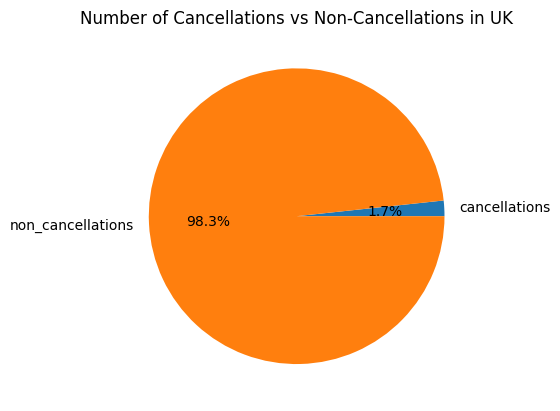

In [46]:
df_cancellations = df[df["is_cancellation"]].copy()
non_cancel_df = df[~df["is_cancellation"]].copy()

pd.Series(
    {"cancellations": len(df_cancellations), "non_cancellations": len(non_cancel_df)}
).plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Number of Cancellations vs Non-Cancellations in UK",
);

In [57]:
df_cancellations.describe()


,Quantity,InvoiceDate,Price,Customer ID,Hour
count,16650.000000,16650,16650.000000,16650.000000,16650.000000
mean,-22.118859,2010-12-07 21:21:56.198198016,45.504059,14732.604805,13.270270
min,-80995.000000,2009-12-01 10:44:00,0.010000,-1.000000,6.000000
25%,-6.000000,2010-06-02 21:30:00,1.490000,13798.000000,11.000000
50%,-2.000000,2010-11-25 18:53:00,2.950000,15154.000000,13.000000
75%,-1.000000,2011-06-21 10:39:00,6.750000,16600.000000,15.000000
max,1.000000,2011-12-09 11:58:00,38970.000000,18287.000000,21.000000
std,859.723944,NaN,632.690011,3342.187117,2.756345


# 3. NON-CANCELLATIONS

This section analyzes regular transactions using `is_cancellation == False`.

## Non-Cancellation Summary
Review baseline descriptive statistics for regular (non-cancelled) transactions.

In [58]:
non_cancel_df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Hour
count,964680.000000,964680,964680.000000,964680.000000,964680.000000
mean,9.392912,2011-01-01 19:12:46.511444224,3.830832,11697.860614,13.107735
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,-1.000000,6.000000
25%,1.000000,2010-07-07 16:14:00,1.250000,12748.000000,11.000000
50%,3.000000,2010-12-06 16:58:00,2.100000,14606.000000,13.000000
75%,10.000000,2011-07-21 10:44:00,4.130000,16539.000000,15.000000
max,80995.000000,2011-12-09 12:49:00,25111.090000,18287.000000,20.000000
std,132.459451,NaN,96.969711,6861.618269,2.416905


## Summary

1. We found that the lion's share of the data is UK data, so we decided to discard all other countries.

2. Overall data quality is excellent - no missing values, no duplicates, and we have plenty of transactions.

3. A large portion of transactions have no associated customer - they are guest customers.

4. Some early insights:
    - Distribution of Day of Week of Transactions aligns with expectations (common knowledge as an occasional shopper)
    - Distribution of Month of Year: we can see some patterns, it's not equal
    - Distribution of Hour of Day: bell-like shape around 12:00
    - Distribution of StockCode Frequencies is very skewed
    - Distribution of Total Sum per Invoice is symmetric for cancelled and fulfilled orders
    